# 1 Analise inicial

## 1.1 Os datasets

Antes de iniciarmos o tratamento de dados de verdade, precisamos entender os datasets.

No repositório de [dados](https://repositorio.dados.gov.br/seges/comprasgov/anual/) do ComprasGov, a partir de 2021, existe uma pasta por ano com os seguintes datasets:

1. COMPRA
2. COMPRA_ITEM
3. ITEM_RESULTADO

Eles se relacionamento basicamente assim:

**COMPRA <1-n> COMPRA_ITEM <1-n> ITEM_RESULTADO**

Ou seja, uma compra pode ter vários itens e um item pode ter vários resultados (de vários fornecedores, por exemplo).

Além desses há também o dataset [catser](https://repositorio.dados.gov.br/seges/comprasgov/catalogo_cnbs/catser.csv), onde é possível identificar os códigos de grupo e classe e decidir se corresponde a software.

### 1.1.1 COMPRA

Esse dataset é o de nível mais alto, trazendo informações sobre as contratações por inteiro, como a qual orgão se refere, qual objeto geral da compra, quando foi homologada, etc.

Alguns campos que podem ser importantes são:

- id_compra — identificador da compra no Compras.gov.
- numero_controle_PNCP — identificador da contratação no PNCP.
- numero_compra — número atribuído à compra.
- ano_compra_pncp — ano da contratação no PNCP.
- sequencial_compra_pncp — número sequencial da contratação no PNCP.
- processo — número do processo administrativo.
- codigo_orgao — código do órgão responsável.
- unidade_orgao_codigo_unidade — código da unidade compradora/UASG.
- unidade_orgao_uf_sigla — UF da unidade compradora.
- codigo_modalidade — código da modalidade da contratação.
- codigo_modo_disputa — código do modo de disputa.
- amparo_legal_codigo_pncp — código do fundamento legal.
- objeto_compra — descrição geral do objeto da contratação.
- informacao_complementar — informações adicionais sobre a contratação.
- srp — indica uso do Sistema de Registro de Preços.
- valor_total_estimado — valor total estimado da contratação.
- valor_total_homologado — valor total efetivamente homologado.
- existe_resultado — indica se a contratação já possui resultado.
- situacao_compra_nome_pncp — situação atual da contratação.
- data_publicacao_pncp — data de publicação no PNCP.
- data_inclusao_pncp — data de inclusão no PNCP.
- data_atualizacao_pncp — última atualização no PNCP.
- data_abertura_proposta_pncp — início do recebimento de propostas.
- data_encerramento_proposta_pncp — fim do recebimento de propostas.

### 1.1.2 COMPRA_ITEM

O dataset de COMPRA_ITEM é o mais importante para nós, pois detalha a compra com seus itens (que podem ser de diferentes divisões, grupos, classes...).

Assim sendo é possível extrair informações valiosas a partir de dados como:

- id_compra — identifica a contratação à qual o item pertence.
- id_compra_item — identificador único do item.
- id_contratacao_pncp — identificador da contratação no PNCP.
- numero_item_pncp — número do item no PNCP.
- numero_item_compra — número do item dentro da compra.
- numero_grupo — grupo/lote do item dentro daquela contratação.
- descricao_resumida — descrição curta do item.
- descricao_detalhada — descrição detalhada do item.
- material_ou_servico — indica M para material ou S para serviço.
- material_ou_servico_nome — descrição do tipo material/serviço.
- codigo_grupo — grupo do item no CATMAT/CATSER.
- codigo_classe — classe do item no CATMAT/CATSER.
- cod_item_catalogo — código específico CATMAT/CATSER do item.
- unidade_medida — unidade usada para a contratação.
- quantidade — quantidade prevista.
- valor_unitario_estimado — valor estimado por unidade.
- valor_total — valor total estimado do item.
- orcamento_sigiloso — indica se o orçamento do item é sigiloso.
- item_categoria_id_pncp — código da categoria do item no PNCP.
- item_categoria_nome — descrição da categoria.
- criterio_julgamento_id_pncp — código do critério de julgamento.
- tem_resultado — indica se o item possui resultado/homologação.

### 1.1.3 ITEM_RESULTADO

Já o dataset de ITEM_RESULTADO traz os resultados de cada item, ou seja, quais fornecedores foram selecionados para cada item, sendo que um item pode ter mais de um fornecedor, de maneira que a quantidade esteja divida entre eles, por exemplo.

Desse dataset, as colunas importantes identificadas foram:

- id_compra — contratação à qual o resultado pertence.
- id_compra_item — item ao qual o resultado pertence.
- sequencial_resultado — identifica o resultado dentro daquele item.
- ni_fornecedor — CNPJ/CPF ou outro identificador do fornecedor.
- nome_razao_social_fornecedor — nome/razão social do fornecedor.
- tipo_pessoa_id — tipo de pessoa do fornecedor.
- porte_fornecedor_id — porte do fornecedor, como ME/EPP.
- natureza_juridica_id — natureza jurídica do fornecedor.
- codigo_pais — país do fornecedor, quando aplicável.
- quantidade_homologada — quantidade efetivamente homologada.
- valor_unitario_homologado — valor unitário vencedor/homologado.
- valor_total_homologado — valor total homologado.
- percentual_desconto — percentual de desconto obtido.
- ordem_classificacao_srp — posição do fornecedor no SRP, quando aplicável.
- indicador_subcontratacao — indica existência de subcontratação.
- data_resultado — data do resultado.
- situacao_compra_item_resultado_id — situação do resultado.
- justificativa — justificativa associada ao resultado, quando existente.

## 1.2 Considerações sobre os datasets

É importante perceber que alguns desses campos não vão servir para a clusterização, como as descrições textuais ou nomes.
Porém, em uma primeira análise, pode ser útil manter esses campos para identificar o que está na categoria de "serviços relacionados a software e TIC (Tecnologia da Informação e Comunicação)" ou não.

## 1.3 Identificando o que é serviço relacionado a software e TIC

Primeiro é necessário entender a hierarquia da identificação de serviço nos nossos datasets.

O ComprasGov usa a seguinte hierarquia no seu [catálogo de serviços](https://dadosabertos.compras.gov.br/swagger-ui/index.html#/02%20-%20CAT%C3%81LOGO%20-%20SERVI%C3%87O):
**Seção -> Divisão -> Grupo -> Classe -> Subclasse -> Item**

Em resumo, cada nível é detalhado pelo nível seguinte, por exemplo:

```
[
    {
      "codigoSecao": 1,
      "nomeSecao": "SERVIÇOS DE TECNOLOGIA DA INFORMAÇÃO E COMUNICAÇÃO - TIC",
    },
    {
      "codigoSecao": 5,
      "nomeSecao": "SERVIÇO DE CONSTRUÇÃO",
    },
    ...
]
```

Cada uma dessas grandes seções contém divisões:

```
[
    {
      "codigoSecao": 1,
      "nomeSecao": "SERVIÇOS DE TECNOLOGIA DA INFORMAÇÃO E COMUNICAÇÃO - TIC",
      "codigoDivisao": 11,
      "nomeDivisao": "SERVIÇOS  DE DESENVOLVIMENTO,  MANUTENÇÃO  E  SUSTENTAÇÃO DESOFTWARE",
    },
    {
      "codigoSecao": 1,
      "nomeSecao": "SERVIÇOS DE TECNOLOGIA DA INFORMAÇÃO E COMUNICAÇÃO - TIC",
      "codigoDivisao": 13,
      "nomeDivisao": "SERVIÇOS DE COMPUTAÇÃO EM NUVEM",
    },
    {
      "codigoSecao": 1,
      "nomeSecao": "SERVIÇOS DE TECNOLOGIA DA INFORMAÇÃO E COMUNICAÇÃO - TIC",
      "codigoDivisao": 14,
      "nomeDivisao": "SERVIÇOS DE TELECOMUNICAÇÃO E TELEFONIA",
    },
  ...
  ]
```

E assim sucessivamente, detalhando o que cada serviço é de maneira padronizada.

Percebendo isso, nossa equipe precisou identificar quais seções, divisões e grupos correspondem ao nosso escopo, obtendo o seguinte resultado:

`Tipo: Nome (ID)`

- Seção: SERVIÇOS DE TECNOLOGIA DA INFORMAÇÃO E COMUNICAÇÃO - TIC (1)
  - Divisão: SERVIÇOS  DE DESENVOLVIMENTO,  MANUTENÇÃO  E  SUSTENTAÇÃO DESOFTWARE (11)
    - Grupo: SERVIÇOS  DE DESENVOLVIMENTO E MANUTENÇÃO DE SOFTWARE ( 111 )
    - Grupo: SERVIÇOS DE MANUTENÇÃO E SUSTENTAÇÃO DE SOFTWARE ( 112 )
    - Grupo: SERVIÇOS DE DOCUMENTAÇAO DE SOFTWARE ( 113 )
    - Grupo: SERVIÇOS SE ENGENHARIA DE REQUISITOS DE SOFTWARE ( 114 )
    - Grupo: SERVIÇOS DE MENSURAÇÃO DE SOFTWARE ( 115 )
    - Grupo: SERVIÇOS DE QUALIDADE DE SOFTWARE ( 116 )
    - Grupo: SERVIÇO DE IMPLEMENTAÇÃO ÁGIL DE SOFTWARE ( 117 )

  - Divisão: SERVIÇOS DE COMPUTAÇÃO EM NUVEM (13)
    - Grupo: SERVIÇOS DE COMPUTAÇÃO EM NUVEM ( 131 )

  - Divisão: SERVIÇOS PARA A INFRAESTRUTURA  DE  TECNOLOGIA DA INFORMAÇÃOE COMUNICAÇÃO (TIC) (16)
    - Grupo: SERVIÇOS ESPECIALIZADOS DE INSTALAÇÃO, TRANSIÇÃO, CONFIGURA-ÇÃO / CUSTOMIZAÇÃO DE SOFTWARE ( 161 )
    - Grupo: SERVIÇOS  DE  GERENCIAMENTO  EM TECNOLOGIA DA INFORMAÇÃO  E COMUNICAÇÃO (TIC) ( 162 )
    - Grupo: SERVIÇOS DE HOSPEDAGEM EM TECNOLOGIA DA INFORMAÇÃO E  COMUNICACÃO (TIC) ( 163 )
    - Grupo: SERVIÇOS DE INTEGRAÇÃO DE SISTEMAS EM TECNOLOGIA DA INFORMA-ÇÃO E COMUNICAÇÃO (TIC) ( 164 )
    - Grupo: SERVICOS PARA  A  INFRAESTRUTURA DE TECNOLOGIA DA INFORMAÇÃOE COMUNICAÇÃO (TIC),  NAO CLASSIFICADOS EM OUTROS TÓPICOS ( 165 )

  - Divisão: SERVIÇOS DE  PESQUISA,  ANÁLISE  DE  DADOS  E  INDICADORES, CONSULTORIA E PROJETOS DE TIC (17)
    - Grupo: SERVIÇOS DE PESQUISA,ANÁLISE E DESENVOLVIMENTO EM TECNOLOGIADA INFORMAÇÃO E COMUNICAÇÃO (TIC) ( 172 )
    - Grupo: SERVIÇOS  DE  CONSULTORIA  EM  TECNOLOGIA  DA  INFORMAÇÃO  ECOMUNICAÇÃO (TIC) ( 173 )

---

Decidimos usar apenas até grupo por dois motivos:

1. No dataset de item há a informação do grupo
2. Mais profundo do que isso há muita repetição/detalhamento que não nos ajudaria.


# 2 Integração das bases de 2021 a 2026


## 2.1 Preparar os arquivos filtrados
O ZIP compartilhado no Drive contém os CSVs anuais de COMPRA e COMPRA_ITEM previamente recortados e o CATSER. Os arquivos presentes são reutilizados; a seleção dos 15 grupos é aplicada em 2.2.4. As fontes e o procedimento de preparação são descritos no relatório.

In [ ]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import zipfile

ROOT = Path("/content/topicos_software")
RECORTE = ROOT / "dados/recorte_software"
CATSER = ROOT / "dados/catser.csv"
SAIDA = ROOT / "dados/integrados"
preparado = ROOT / ".preparacao_recorte_v2"
esperados = [CATSER, RECORTE / "codigos_software.csv"] + [
    RECORTE / str(ano) / f"comprasGOV-anual-VW_FT_PNCP_{tabela}-{ano}.csv"
    for ano in range(2021, 2027) for tabela in ("COMPRA", "COMPRA_ITEM")
]

if not (preparado.is_file() and all(arquivo.is_file() for arquivo in esperados)):
    if importlib.util.find_spec("gdown") is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], capture_output=True, check=True)
    import gdown

    ROOT.mkdir(parents=True, exist_ok=True)
    pacote = ROOT / "colab_software.zip"
    if not gdown.download(id="1AXhxv90bBlgIWLlV0RX0V4JqFhi6wHFB", output=str(pacote), quiet=True):
        raise RuntimeError("O ZIP deve estar compartilhado no Drive com acesso de leitor para qualquer pessoa com o link.")
    with zipfile.ZipFile(pacote) as z:
        z.extractall(ROOT)
    assert all(arquivo.is_file() for arquivo in esperados), "Faltam arquivos no pacote de dados."
    (SAIDA / "itens_2021_2026.parquet").unlink(missing_ok=True)
    preparado.touch()

assert all(arquivo.is_file() for arquivo in esperados), "Faltam arquivos no pacote de dados."
SAIDA.mkdir(parents=True, exist_ok=True)


## 2.2 Integração das bases
Integra o recorte de serviços relacionados a software e TIC de 2021 a 2026. Uma linha representa uma ocorrência do arquivo de origem; versões e resultados distintos do mesmo item são preservados para as etapas seguintes.

### 2.2.1 Configuração

In [ ]:
from decimal import Decimal
import pandas as pd

if importlib.util.find_spec("pyarrow") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"], capture_output=True, check=True)

ANOS = range(2021, 2027)
PROVENIENCIA = ["ano_origem", "registro_no_arquivo", "id_registro_origem"]
ROOT = Path("/content/topicos_software")
RECORTE = ROOT / "dados/recorte_software"
CATSER = ROOT / "dados/catser.csv"
SAIDA = ROOT / "dados/integrados"

### 2.2.2 Carregar e comparar as colunas
Os CSVs são lidos como texto para preservar os identificadores. Campos vazios são ausentes; textos como NA e NULL são mantidos. Após renomear, COMPRA mantém 59 colunas; COMPRA_ITEM passa de 55 para 60 em 2025 e 61 em 2026. O quadro de esquemas registra essas diferenças.

In [ ]:
RENOMEACOES = {
    'COMPRA': {
        nome: nome + '_pncp' for nome in [
            'amparo_legal_codigo', 'ano_compra', 'data_abertura_proposta',
            'data_atualizacao', 'data_encerramento_proposta', 'data_inclusao',
            'modalidade_id', 'modo_disputa_id', 'modo_disputa_nome',
            'sequencial_compra', 'situacao_compra_id', 'situacao_compra_nome',
            'tipo_instrumento_convocatorio_codigo',
        ]
    },
    'COMPRA_ITEM': {
        'criterio_julgamento_id': 'criterio_julgamento_id_pncp',
        'data_atualizacao': 'data_atualizacao_pncp',
        'data_inclusao': 'data_inclusao_pncp',
        'descricao': 'descricao_resumida',
        'item_categoria_id': 'item_categoria_id_pncp',
        'numero_item': 'numero_item_pncp',
    },
}

bases = {"COMPRA": [], "COMPRA_ITEM": []}
esquemas = []
for dataset in bases:
    referencia = None
    for ano in ANOS:
        arquivo = RECORTE / str(ano) / f"comprasGOV-anual-VW_FT_PNCP_{dataset}-{ano}.csv"
        tabela = pd.read_csv(arquivo, dtype="string", keep_default_na=False, na_values=[""], encoding="utf-8-sig")
        renomeacoes = {c: RENOMEACOES[dataset][c] for c in tabela if c in RENOMEACOES[dataset]}
        tabela = tabela.rename(columns=renomeacoes)
        assert tabela.columns.is_unique, "A renomeação produziu colunas repetidas."
        colunas = set(tabela.columns)
        if referencia is None:
            referencia = colunas
        esquemas.append({"dataset": dataset, "ano_origem": ano, "colunas": len(colunas),
                         "adicionais": ", ".join(sorted(colunas - referencia)),
                         "ausentes": ", ".join(sorted(referencia - colunas)),
                         "renomeacoes": "; ".join(f"{a} → {b}" for a, b in renomeacoes.items())})
        tabela["ano_origem"] = pd.Series(ano, index=tabela.index, dtype="Int64")
        tabela["registro_no_arquivo"] = pd.Series(range(1, len(tabela) + 1), dtype="Int64")
        tabela["id_registro_origem"] = str(ano) + ":" + dataset + ":" + tabela["registro_no_arquivo"].astype("string")
        bases[dataset].append(tabela)
esquemas = pd.DataFrame(esquemas)

### 2.2.3 Padronizar os tipos
Datas são convertidas para comparação e valores para Decimal. Códigos continuam como texto, removendo apenas o sufixo decimal de zeros. Colunas adicionais são mantidas. `ano_origem` identifica o arquivo anual; o ano da contratação permanece em seu próprio campo. A cobertura de 2026 corresponde à extração utilizada, descrita no relatório.

In [ ]:
DATAS = ["data_atualizacao_pncp", "data_publicacao_pncp", "data_inclusao_pncp",
         "data_abertura_proposta_pncp", "data_encerramento_proposta_pncp", "data_resultado"]
NUMERICAS = ["valor_total_estimado", "valor_total_homologado", "valor_unitario_estimado",
             "valor_total", "quantidade", "valor_total_resultado", "valor_unitario_resultado", "quantidade_resultado"]
CODIGOS = [
    "cod_compra", "modalidade_id_pncp", "modo_disputa_id_pncp", "id_compra", "orgao_subrogado_cnpj",
    "orgao_subrogado_esfera_id", "orgao_subrogado_poder_id", "codigo_orgao", "unidade_orgao_codigo_unidade",
    "unidade_orgao_codigo_ibge", "unidade_subrogada_codigo_unidade", "unidade_subrogada_codigo_ibge",
    "codigo_modo_disputa", "codigo_modalidade", "sequencial_compra_pncp", "orgao_entidade_cnpj",
    "orgao_entidade_esfera_id", "orgao_entidade_poder_id", "amparo_legal_codigo_pncp",
    "orcamento_sigiloso_codigo", "situacao_compra_id_pncp", "tipo_instrumento_convocatorio_codigo_pncp",
    "srk_pncp_item_compra", "cod_item_compra", "codigo_classe", "codigo_grupo", "numero_item_pncp",
    "numero_grupo", "numero_item_compra", "item_categoria_id_pncp", "codigo_registro_imobiliario",
    "criterio_julgamento_id_pncp", "cod_item_catalogo", "cod_fornecedor", "id_compra_item",
    "sequencial_compra", "codigo_NCM", "codigo_grupo_catser", "codigo_classe_catser", "COD_RESULTADO_ITEM",
]

def decimal_exato(valor):
    if pd.isna(valor):
        return None
    numero = Decimal(valor)
    if not numero.is_finite():
        raise ValueError(f"Número inválido: {valor}")
    return numero

for tabelas in bases.values():
    for tabela in tabelas:
        for coluna in tabela.columns.intersection(DATAS):
            tabela[coluna] = pd.to_datetime(tabela[coluna], format="ISO8601", errors="raise")
        for coluna in tabela.columns.intersection(NUMERICAS):
            tabela[coluna] = tabela[coluna].map(decimal_exato)
        for coluna in tabela.columns.intersection(CODIGOS):
            tabela[coluna] = tabela[coluna].str.replace(r"^(\d+)\.0+$", r"\1", regex=True)
        for coluna in tabela.columns.intersection(["ano_compra", "ano_compra_pncp"]):
            tabela[coluna] = tabela[coluna].str.replace(r"\.0+$", "", regex=True).astype("Int64")

### 2.2.4 Concatenar e conferir o recorte
Compras e itens são concatenados separadamente. O recorte operacional inclui os 15 grupos CATSER definidos na etapa 1, abrangendo software e serviços relacionados de TIC, como nuvem, infraestrutura e consultoria. Serviços inativos são mantidos para análise histórica. A seção verifica os códigos e aplica essa seleção ao pacote recebido.

In [ ]:
compras_todas = pd.concat(bases["COMPRA"], ignore_index=True, sort=False)
itens = pd.concat(bases["COMPRA_ITEM"], ignore_index=True, sort=False)
assert compras_todas["id_registro_origem"].is_unique and itens["id_registro_origem"].is_unique

GRUPOS_SOFTWARE = {"111", "112", "113", "114", "115", "116", "117", "131",
                   "161", "162", "163", "164", "165", "172", "173"}
catalogo = pd.read_csv(CATSER, sep=";", dtype="string", keep_default_na=False, na_values=[""], encoding="utf-8-sig")
for coluna in ("codigoGrupo", "codigoServico"):
    catalogo[coluna] = catalogo[coluna].str.replace(r"^(\d+)\.0+$", r"\1", regex=True)
assert GRUPOS_SOFTWARE.issubset(set(catalogo["codigoGrupo"]))
codigos = set(catalogo.loc[catalogo["codigoGrupo"].isin(GRUPOS_SOFTWARE), "codigoServico"].dropna())
codigos_pacote = set(pd.read_csv(RECORTE / "codigos_software.csv", dtype="string")["codigoServico"])
assert codigos.issubset(codigos_pacote), "O pacote não cobre todos os códigos selecionados. Atualize os dados."
assert itens["material_ou_servico"].eq("S").all() and itens["cod_item_catalogo"].isin(codigos_pacote).all(), "Entradas incompatíveis: execute a seção 2.1 e depois toda a 2.2 em ordem."
itens = itens.loc[itens["cod_item_catalogo"].isin(codigos)].copy()
compras_todas = compras_todas.loc[compras_todas["id_compra"].isin(itens["id_compra"])].copy()

### 2.2.5 Selecionar atualizações e relacionar
As compras são identificadas por `id_compra` e controle PNCP; seleciona-se sua maior atualização disponível. Empates com conteúdo divergente interrompem a integração. O join associa os itens por esses dois campos e mantém os que não encontram compra. Todas as ocorrências de itens são preservadas, incluindo os campos de resultado já presentes em COMPRA_ITEM. ITEM_RESULTADO não participa de outro join nesta seção.

In [ ]:
CHAVE_COMPRA = ["id_compra", "numero_controle_PNCP"]
assert not compras_todas[CHAVE_COMPRA].isna().any().any()
assert not itens[["id_compra", "id_compra_item"]].isna().any().any()
assert itens.groupby("id_compra_item")["id_compra"].nunique().le(1).all()

ultima_data = compras_todas.groupby(CHAVE_COMPRA)["data_atualizacao_pncp"].transform("max")
ultimas = compras_todas.loc[compras_todas["data_atualizacao_pncp"].eq(ultima_data) | ultima_data.isna()]
assert not ultimas.drop(columns=PROVENIENCIA).drop_duplicates().duplicated(CHAVE_COMPRA).any(), "Atualizações conflitantes."
compras = (compras_todas.sort_values(CHAVE_COMPRA + ["data_atualizacao_pncp", "ano_origem", "registro_no_arquivo"],
                                    na_position="first", kind="stable")
           .drop_duplicates(CHAVE_COMPRA, keep="last").reset_index(drop=True))

In [ ]:
compras_join = compras.rename(columns={c: "compra_" + c for c in compras if c != "id_compra"})
base_integrada = itens.merge(compras_join, left_on=["id_compra", "ID_contratacao_PNCP"],
                            right_on=["id_compra", "compra_numero_controle_PNCP"],
                            how="left", validate="many_to_one", indicator="relacionamento_compra", sort=False)
base_integrada["relacionamento_compra"] = base_integrada["relacionamento_compra"].astype("string")
base_integrada["compra_encontrada"] = base_integrada["relacionamento_compra"].eq("both").astype("boolean")
base_integrada["item_id_repetido"] = base_integrada["id_compra_item"].duplicated(keep=False).astype("boolean")
base_integrada["item_ocorrencias"] = base_integrada.groupby("id_compra_item")["id_compra_item"].transform("size").astype("Int64")

assert len(base_integrada) == len(itens)
assert base_integrada["id_registro_origem"].tolist() == itens["id_registro_origem"].tolist()
encontrados = base_integrada.loc[base_integrada["compra_encontrada"]]
assert encontrados["ID_contratacao_PNCP"].eq(encontrados["compra_numero_controle_PNCP"]).all()
itens_sem_compra = base_integrada.loc[~base_integrada["compra_encontrada"]]

### 2.2.6 Conferir o resultado
Confere a quantidade e a ordem das ocorrências antes e depois do join, a correspondência PNCP e as contagens por ano. O relacionamento aceita no máximo uma compra por chave, evitando multiplicação de itens. Repetições e itens sem compra são preservados para avaliação na seção 3.

In [ ]:
contagens = pd.DataFrame([
    {"ano_origem": ano, "compras_antes": int(compras_todas["ano_origem"].eq(ano).sum()),
     "compras_selecionadas": int(compras["ano_origem"].eq(ano).sum()),
     "itens_antes": int(itens["ano_origem"].eq(ano).sum()),
     "itens_depois": int(base_integrada["ano_origem"].eq(ano).sum()),
     "itens_distintos": int(itens.loc[itens["ano_origem"].eq(ano), "id_compra_item"].nunique()),
     "itens_sem_compra": int(itens_sem_compra["ano_origem"].eq(ano).sum())}
    for ano in ANOS
])
assert contagens["itens_antes"].equals(contagens["itens_depois"])
display(contagens)

,ano_origem,compras_antes,compras_selecionadas,itens_antes,itens_depois,itens_distintos,itens_sem_compra
0,2021,18,18,19,19,19,0
1,2022,203,203,240,240,239,0
2,2023,1083,1081,596,596,588,0
3,2024,2817,2801,3967,3967,3876,1
4,2025,3467,3437,11404,11404,11146,112
5,2026,211,211,1703,1703,778,18


### 2.2.7 Salvar a base integrada
Salva `dados/integrados/itens_2021_2026.parquet` e baixa sua cópia em ZIP. A seção 3 preserva as ocorrências na base tratada e prepara uma base com um registro por item para analisar estimativas.

In [ ]:
from google.colab import files

arquivo = SAIDA / "itens_2021_2026.parquet"
base_integrada.to_parquet(arquivo, engine="pyarrow", index=False, compression="snappy")

entrega = ROOT / "entrega_integracao.zip"
with zipfile.ZipFile(entrega, "w", zipfile.ZIP_DEFLATED) as pacote:
    pacote.write(arquivo, "integrados/" + arquivo.name)
files.download(str(entrega))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 3 Qualidade e limpeza estrutural dos dados
Diagnostica a base integrada e aplica os tratamentos aprovados em uma cópia. A base tratada conserva versões e resultados. Uma segunda base reúne uma observação por contratação PNCP + número do item para as estatísticas de estimativas. Itens sem compra e zeros continuam disponíveis; conflitos de preço ficam fora dessa segunda base.

## 3.1 Carregar a base integrada
Lê diretamente o Parquet produzido na seção 2.

In [ ]:
from pathlib import Path
from decimal import Decimal
import pandas as pd

arquivo_integrado = Path("/content/topicos_software/dados/integrados/itens_2021_2026.parquet")
assert arquivo_integrado.is_file(), "Execute a seção 2 antes da análise de qualidade."
df = pd.read_parquet(arquivo_integrado)
total = len(df)

## 3.2 Ausências e tipos
Calcula ausências por coluna e por ano. A tabela mostra até dez colunas com maior percentual de ausência. Campos de resultado podem faltar antes da homologação, e colunas novas podem estar ausentes nos anos anteriores. Nenhuma coluna é excluída automaticamente.

In [ ]:
resumo_colunas = pd.DataFrame({
    "tipo": df.dtypes.astype(str), "ausentes": df.isna().sum(),
    "ausentes_pct": df.isna().mean().mul(100).round(2), "valores_distintos": df.nunique()
}).rename_axis("coluna").reset_index()
resumo_colunas["acao_proposta"] = [
    "Sem tratamento de ausências." if n == 0 else "Avaliar retirar da análise por ausência total." if n == total
    else "Conferir se a ausência é esperada antes de imputar." for n in resumo_colunas["ausentes"]
]
ausentes_por_ano = df.isna().groupby(df["ano_origem"]).mean().mul(100).round(2)
colunas_vazias = resumo_colunas.loc[resumo_colunas["ausentes"].eq(total), "coluna"].tolist()
display(resumo_colunas.loc[resumo_colunas["ausentes"].gt(0), ["coluna", "tipo", "ausentes", "ausentes_pct"]]
        .sort_values("ausentes_pct", ascending=False, kind="stable").head(10).reset_index(drop=True))

,coluna,tipo,ausentes,ausentes_pct
0,codigo_classe,string,17929,100.00
1,patrimonio,string,17929,100.00
2,codigo_registro_imobiliario,string,17929,100.00
3,codigo_NCM,string,17929,100.00
4,descricao_NCM,string,17929,100.00
5,TXT_LINK_MATERIAL,string,17929,100.00
6,TXT_LINK_CLASSE,string,17929,100.00
7,compra_justificativa_presencial,string,17929,100.00
8,percentual_margem_preferencia_adicional,string,17921,99.96
9,compra_orgao_subrogado_cnpj,string,17890,99.78


## 3.3 Duplicatas e identificadores
Diagnóstico e tratamento comparam as mesmas colunas, ignorando somente `registro_no_arquivo` e `id_registro_origem`. O ano e os demais campos permanecem na comparação. Repetição de ID não equivale a cópia de conteúdo: pode envolver versões, resultados ou cadastros PNCP distintos.

In [ ]:
colunas_ignorar_duplicata = ["registro_no_arquivo", "id_registro_origem"]
duplicatas_conteudo = df.drop(columns=colunas_ignorar_duplicata).duplicated()
ids_item_repetidos = df["id_compra_item"].duplicated(keep=False)
origem_invalida = df["id_registro_origem"].isna() | df["id_registro_origem"].duplicated(keep=False)
identificadores_ausentes = df[["id_compra", "id_compra_item", "ID_contratacao_PNCP"]].isna().any(axis=1)

## 3.4 Datas, valores e categorias
Confere datas fora de ordem, negativos, zeros e totais diferentes de quantidade × valor unitário, com tolerância de R$ 0,01. São sinais para investigação; descontos, arredondamento e orçamento sigiloso precisam ser considerados. As comparações monetárias mantêm Decimal.

In [ ]:
datas = [c for c in df if c.removeprefix("compra_").startswith("data_")]
datas_convertidas = df[datas].apply(pd.to_datetime, format="ISO8601", errors="coerce")
datas_invalidas = (df[datas].notna() & datas_convertidas.isna()).any(axis=1)
pares_datas = [("data_inclusao_pncp", "data_atualizacao_pncp"),
               ("compra_data_inclusao_pncp", "compra_data_atualizacao_pncp"),
               ("compra_data_abertura_proposta_pncp", "compra_data_encerramento_proposta_pncp")]
datas_invertidas = pd.DataFrame({a: datas_convertidas[a].gt(datas_convertidas[b]) for a, b in pares_datas}).any(axis=1)

colunas_valor = [c for c in df if c.removeprefix("compra_").startswith("valor_")
                 or c.removeprefix("compra_") in ["quantidade", "quantidade_resultado"]]
valores = df[colunas_valor]
valores_negativos = valores.lt(0).any(axis=1)
valores_zero = valores.eq(0).any(axis=1)
total_estimado_divergente = (df["quantidade"] * df["valor_unitario_estimado"] - df["valor_total"]).abs().gt(Decimal("0.01"))
total_resultado_divergente = (df["quantidade_resultado"] * df["valor_unitario_resultado"] - df["valor_total_resultado"]).abs().gt(Decimal("0.01"))
campos_resultado = ["valor_total_resultado", "valor_unitario_resultado", "quantidade_resultado", "data_resultado", "cod_fornecedor"]
resultado_incompleto = df["tem_resultado"].eq("True").fillna(False) & df[campos_resultado].isna().any(axis=1)

pares_categorias = [("codigo_grupo_catser", "nome_grupo_catser"), ("cod_item_catalogo", "nome_servico_catser"),
                   ("situacao_compra_item", "situacao_compra_item_nome"), ("material_ou_servico", "material_ou_servico_nome")]
categorias_divergentes = pd.Series(False, index=df.index)
for codigo, nome in pares_categorias:
    rotulos = df.groupby(codigo)[nome].nunique()
    categorias_divergentes |= df[codigo].isin(rotulos.index[rotulos.gt(1)])

## 3.5 Textos e formatos
Conta os registros que seriam afetados por remover espaços externos ou converter textos formados só por espaços em ausentes. A conferência dos códigos procura o sufixo decimal indevido, preservando zeros à esquerda.

In [ ]:
textos = df.select_dtypes(include="string")
textos_sem_espacos = textos.apply(lambda coluna: coluna.str.strip())
espacos_externos = textos.ne(textos_sem_espacos).fillna(False).any(axis=1)
so_espacos = textos_sem_espacos.eq("").fillna(False).any(axis=1)
colunas_codigo = [c for c in textos if c.removeprefix("compra_").startswith(("id_", "cod_", "codigo_", "srk_"))
                  or c.endswith(("_id", "_id_pncp", "_cnpj")) or c == "COD_RESULTADO_ITEM"]
codigos_com_decimal = textos[colunas_codigo].apply(lambda coluna: coluna.str.fullmatch(r"\d+\.0+", na=False)).any(axis=1)

## 3.6 Diagnóstico e decisões de tratamento
O quadro resume o diagnóstico da base original e o encaminhamento de cada problema. As contagens podem se sobrepor e representam linhas afetadas; cópias de conteúdo contam somente as excedentes. Os tratamentos aprovados são aplicados em 3.7. As demais ocorrências permanecem para investigação ou filtros por finalidade.

In [ ]:
regras = [
    ("Origem repetida ou ausente", origem_invalida, "Revisar a integração antes de tratar."),
    ("Identificadores ausentes", identificadores_ausentes, "Conferir a fonte; não inventar identificadores."),
    ("Item sem compra", ~df["compra_encontrada"], "Manter sinalizado e investigar a compra na fonte."),
    ("Conteúdo repetido excedente", duplicatas_conteudo, "Remover cópias excedentes conforme a comparação validada."),
    ("Observações com ID de item repetido", ids_item_repetidos, "Separar versões e resultados antes de decidir."),
    ("Datas inválidas ou fora de ordem", datas_invalidas | datas_invertidas, "Conferir datas na fonte."),
    ("Valores ou quantidades negativos", valores_negativos, "Investigar antes de corrigir ou excluir."),
    ("Valores ou quantidades iguais a zero", valores_zero, "Verificar orçamento sigiloso, situação e significado do zero."),
    ("Total estimado divergente", total_estimado_divergente, "Derivar o unitário de total / quantidade nos casos investigados; preservar quantidade e total."),
    ("Total do resultado divergente", total_resultado_divergente, "Aplicar somente a correção documental do LNCC; investigar outros casos."),
    ("Resultado informado, mas incompleto", resultado_incompleto, "Aplicar o ajuste específico de disponibilidade aprovado; manter os detalhes ausentes."),
    ("Código com rótulos diferentes", categorias_divergentes, "Conferir categorias e catálogo antes de padronizar."),
    ("Textos com espaços externos", espacos_externos, "Remover somente os espaços externos."),
    ("Textos formados só por espaços", so_espacos, "Converter texto vazio em ausente."),
    ("Códigos com sufixo decimal", codigos_com_decimal, "Remover apenas o sufixo .0, preservando zeros à esquerda."),
]
regras_limpeza = pd.DataFrame([
    {"problema": nome, "registros": int(mascara.sum()),
     "percentual": round(float(mascara.mean() * 100), 3), "acao_proposta": acao}
    for nome, mascara, acao in regras
])
display(regras_limpeza.loc[regras_limpeza["registros"].gt(0)].reset_index(drop=True))

,problema,registros,percentual,acao_proposta
0,Item sem compra,131,0.731,Manter sinalizado e investigar a compra na fonte.
1,Conteúdo repetido excedente,58,0.323,Remover cópias excedentes conforme a comparaçã...
2,Observações com ID de item repetido,2825,15.757,Separar versões e resultados antes de decidir.
3,Valores ou quantidades iguais a zero,564,3.146,"Verificar orçamento sigiloso, situação e signi..."
4,Total estimado divergente,785,4.378,Derivar o unitário de total / quantidade nos c...
5,Total do resultado divergente,1,0.006,Aplicar somente a correção documental do LNCC;...
6,"Resultado informado, mas incompleto",1,0.006,Aplicar o ajuste específico de disponibilidade...
7,Textos com espaços externos,10655,59.429,Remover somente os espaços externos.
8,Textos formados só por espaços,1,0.006,Converter texto vazio em ausente.


## 3.7 Aplicar tratamentos na base tratada
Aplica `strip`, converte textos vazios em ausentes e remove cópias de conteúdo. A investigação dos 785 casos estimados mostrou que truncar `total / quantidade` reproduz o unitário recebido; o preço tratado é derivado dessa divisão com dez casas, preservando quantidade e total.

A correção do item único do LNCC usa o [contrato 012/2021, cláusula 3.1](https://www.gov.br/lncc/pt-br/acesso-a-informacao/licitacoes-e-contratos/contratos-1/contrato-1.pdf), que estabelece R$ 30 mil. No único caso de resultado incompleto aprovado pelo grupo, `tem_resultado=False` significa resultado indisponível nesta base para análise, sem afirmar inexistência no PNCP. A base original conserva o indicador recebido.

As alterações usam as colunas existentes. Antes da exportação, conferem-se os textos, as cópias, os identificadores e os totais. Repetições de ID, itens sem compra e zeros são mantidos; as justificativas e pendências detalhadas ficam no relatório.

In [ ]:
df_final = df.copy()
for coluna in df_final.select_dtypes(include="string"):
    df_final[coluna] = df_final[coluna].str.strip().replace("", pd.NA)

duplicatas_conteudo_final = df_final.drop(columns=colunas_ignorar_duplicata).duplicated()
qtd_antes = len(df_final)
qtd_duplicatas_removidas = int(duplicatas_conteudo_final.sum())
df_final = df_final.loc[~duplicatas_conteudo_final].copy()
df_final["item_id_repetido"] = df_final["id_compra_item"].duplicated(keep=False).astype("boolean")
df_final["item_ocorrencias"] = df_final.groupby("id_compra_item")["id_compra_item"].transform("size").astype("Int64")
qtd_ids_item_repetidos_final = int(df_final["item_id_repetido"].sum())
qtd_ids_distintos_repetidos = df_final.loc[df_final["item_id_repetido"], "id_compra_item"].nunique()

# Unitário derivado; quantidade e total recebidos permanecem preservados.
total_estimado_divergente_final = (
    df_final["quantidade"] * df_final["valor_unitario_estimado"] - df_final["valor_total"]
).abs().gt(Decimal("0.01"))
mascara_corrigir_total_estimado = (
    total_estimado_divergente_final
    & df_final["quantidade"].gt(0)
    & df_final["valor_total"].ge(0)
    & df_final["valor_unitario_estimado"].ge(0)
)
qtd_total_estimado_corrigidos = int(mascara_corrigir_total_estimado.sum())
df_final.loc[mascara_corrigir_total_estimado, "valor_unitario_estimado"] = df_final.loc[
    mascara_corrigir_total_estimado
].apply(lambda linha: (linha["valor_total"] / linha["quantidade"]).quantize(Decimal("0.0000000001")), axis=1)

# Compra de item único conferida na base bruta e no contrato do LNCC.
compra_lncc = df_final["ID_contratacao_PNCP"].eq("01263896000164-1-000217/2021")
item_lncc = compra_lncc & df_final["id_compra_item"].eq("2401230700004202100001")
assert item_lncc.sum() == 1 and df_final.loc[compra_lncc, "numero_item_pncp"].nunique() == 1, "Revisar a composição da compra do LNCC."
assert df_final.loc[compra_lncc, "compra_encontrada"].all(), "Compra do LNCC sem correspondência."
assert df_final.loc[item_lncc, "quantidade_resultado"].eq(1).all() and df_final.loc[item_lncc, "valor_unitario_resultado"].eq(30000).all(), "Revisar quantidade e unitário do LNCC."
assert df_final.loc[item_lncc, "valor_total_resultado"].eq(1).all() and df_final.loc[compra_lncc, "compra_valor_total_homologado"].eq(1).all(), "Revisar os totais recebidos do LNCC."
df_final.loc[item_lncc, "valor_total_resultado"] = Decimal("30000")
df_final.loc[compra_lncc, "compra_valor_total_homologado"] = Decimal("30000")
qtd_total_resultado_corrigidos = int(item_lncc.sum())

# Ajuste específico: disponibilidade de resultado para análise nesta base.
mascara_resultado_indisponivel = (
    df_final["id_compra_item"].eq("9900370600027202500001")
    & df_final["ID_contratacao_PNCP"].eq("08036157000189-1-000290/2025")
)
caso = df_final.loc[mascara_resultado_indisponivel]
assert len(caso) == 1 and caso[campos_resultado].isna().all().all(), "Revisar os detalhes do resultado indisponível."
assert caso["tem_resultado"].eq("True").all() and caso["compra_situacao_compra_nome_pncp"].eq("Anulada").all() and caso["situacao_compra_item_nome"].eq("Anulado/Revogado/Cancelado").all(), "Revisar a situação do caso específico."
df_final.loc[mascara_resultado_indisponivel, "tem_resultado"] = "False"
qtd_resultado_indisponivel_ajustado = len(caso)

qtd_total_estimado_divergente_restante = int((
    df_final["quantidade"] * df_final["valor_unitario_estimado"] - df_final["valor_total"]
).abs().gt(Decimal("0.01")).sum())
qtd_total_resultado_divergente_restante = int((
    df_final["quantidade_resultado"] * df_final["valor_unitario_resultado"] - df_final["valor_total_resultado"]
).abs().gt(Decimal("0.01")).sum())
qtd_valores_zero_mantidos = int(df_final[colunas_valor].eq(0).any(axis=1).sum())
qtd_depois = len(df_final)
textos_finais = df_final.select_dtypes(include="string")
validacao_final = pd.Series({
    "Cópias de conteúdo": int(df_final.drop(columns=colunas_ignorar_duplicata).duplicated().sum()),
    "Textos com espaços externos": int(textos_finais.ne(textos_finais.apply(lambda coluna: coluna.str.strip())).fillna(False).any(axis=1).sum()),
    "Textos vazios": int(textos_finais.eq("").fillna(False).any(axis=1).sum()),
    "Origem ausente ou repetida": int((df_final["id_registro_origem"].isna() | df_final["id_registro_origem"].duplicated(keep=False)).sum()),
    "Identificadores ausentes": int(df_final[["id_compra", "id_compra_item", "ID_contratacao_PNCP"]].isna().any(axis=1).sum()),
    "Total estimado divergente": qtd_total_estimado_divergente_restante,
    "Total do resultado divergente": qtd_total_resultado_divergente_restante,
})
assert validacao_final.eq(0).all(), "Revisar a base antes de exportar: " + str(validacao_final[validacao_final.gt(0)].to_dict())
assert qtd_depois == qtd_antes - qtd_duplicatas_removidas and df_final.columns.equals(df.columns), "Revisar as linhas e colunas preservadas."
assert df_final[["quantidade", "valor_total"]].equals(df.loc[df_final.index, ["quantidade", "valor_total"]]), "Quantidade ou total estimado alterados."

resumo_tratamento = pd.DataFrame([
    ("Registros antes", qtd_antes),
    ("Cópias removidas", qtd_duplicatas_removidas),
    ("Registros depois", qtd_depois),
    ("Unitários derivados", qtd_total_estimado_corrigidos),
    ("Itens com total de resultado corrigido", qtd_total_resultado_corrigidos),
    ("Indicadores de disponibilidade ajustados", qtd_resultado_indisponivel_ajustado),
    ("Linhas com ID de item repetido", qtd_ids_item_repetidos_final),
    ("IDs distintos repetidos", qtd_ids_distintos_repetidos),
    ("Itens sem compra mantidos", int((~df_final["compra_encontrada"]).sum())),
    ("Registros com zeros mantidos", qtd_valores_zero_mantidos),
], columns=["Verificação", "Registros"])
display(resumo_tratamento)

,Verificação,Registros
0,Registros antes,17929
1,Cópias removidas,58
2,Registros depois,17871
3,Unitários derivados,785
4,Itens com total de resultado corrigido,1
5,Indicadores de disponibilidade ajustados,1
6,Linhas com ID de item repetido,2755
7,IDs distintos repetidos,1113
8,Itens sem compra mantidos,131
9,Registros com zeros mantidos,562


## 3.8 Consolidar itens para analisar estimativas
A unidade é contratação PNCP + número do item. Seleciona a maior atualização; em empate com uma única situação encerrada, usa essa situação como critério analítico. Dois cancelamentos e dois preços têm encaminhamentos específicos já investigados. Os cinco preços ainda conflitantes ficam fora da análise financeira; a situação conflitante fica ausente somente nesta cópia.

Resultados de fornecedores permanecem na base tratada e não entram nesta tabela de estimativas. Antes de manter um representante, confere se os demais atributos do item são iguais. A origem desempata apenas metadados equivalentes. A investigação completa e as fontes ficam no relatório local.

In [ ]:
CHAVE_ITEM = ["ID_contratacao_PNCP", "numero_item_pncp"]
CAMPOS_RESULTADO = ["tem_resultado", "cod_fornecedor", "nome_fornecedor", "data_resultado",
                    "quantidade_resultado", "valor_unitario_resultado", "valor_total_resultado",
                    "COD_RESULTADO_ITEM"]
assert not df_final[CHAVE_ITEM].isna().any().any(), "Item sem identidade PNCP."

# As estimativas pertencem ao item; resultados de fornecedores ficam na base tratada.
candidatos = df_final.loc[df_final["data_atualizacao_pncp"].eq(
    df_final.groupby(CHAVE_ITEM)["data_atualizacao_pncp"].transform("max")
)].copy()
encerrados = candidatos["situacao_compra_item_nome"].ne("Em andamento")
quantidade_situacoes = candidatos.loc[encerrados].groupby(CHAVE_ITEM)["situacao_compra_item_nome"].nunique()
chaves_encerradas = quantidade_situacoes[quantidade_situacoes.eq(1)].index
chaves_candidatas = pd.MultiIndex.from_frame(candidatos[CHAVE_ITEM])
candidatos = candidatos.loc[encerrados | ~chaves_candidatas.isin(chaves_encerradas)].copy()

# Dois cancelamentos corroborados na investigação da compra e de ITEM_RESULTADO.
cancelamentos_confirmados = {
    "01263896000164-1-000041/2026": "1",
    "09499757000146-1-000056/2025": "3",
}
for pncp, numero in cancelamentos_confirmados.items():
    caso = candidatos["ID_contratacao_PNCP"].eq(pncp) & candidatos["numero_item_pncp"].eq(numero)
    cancelado = candidatos["situacao_compra_item_nome"].eq("Anulado/Revogado/Cancelado")
    assert (caso & cancelado).any(), "Revisar o cancelamento específico: " + pncp
    candidatos = candidatos.loc[~caso | cancelado].copy()

# Estimativas conciliadas com o conjunto completo de itens das respectivas compras.
estimativas_conferidas = {
    ("04696490000163-1-000241/2025", "18"): Decimal("748800"),
    ("91335315000145-1-000155/2025", "1"): Decimal("61169"),
}
for (pncp, numero), valor in estimativas_conferidas.items():
    caso = candidatos["ID_contratacao_PNCP"].eq(pncp) & candidatos["numero_item_pncp"].eq(numero)
    valor_conferido = candidatos["valor_total"].eq(valor)
    assert (caso & valor_conferido).any(), "Revisar a estimativa específica: " + pncp
    candidatos = candidatos.loc[~caso | valor_conferido].copy()

FINANCEIRAS_ITEM = ["quantidade", "valor_unitario_estimado", "valor_total"]
variacoes_financeiras = candidatos.groupby(CHAVE_ITEM)[FINANCEIRAS_ITEM].nunique(dropna=False)
chaves_preco_pendente = variacoes_financeiras.index[variacoes_financeiras.gt(1).any(axis=1)]
situacoes = candidatos.groupby(CHAVE_ITEM)["situacao_compra_item_nome"].nunique(dropna=False)
chaves_situacao_pendente = situacoes.index[situacoes.gt(1)]

pendencias_itens = pd.concat([
    chaves_preco_pendente.to_frame(index=False).assign(pendencia="Estimativas conflitantes: fora da análise financeira"),
    chaves_situacao_pendente.to_frame(index=False).assign(pendencia="Situação conflitante: estimativa pode ser usada uma vez"),
], ignore_index=True)
indices = pd.MultiIndex.from_frame(candidatos[CHAVE_ITEM])
candidatos = candidatos.loc[~indices.isin(chaves_preco_pendente)].copy()
situacao_pendente = pd.MultiIndex.from_frame(candidatos[CHAVE_ITEM]).isin(chaves_situacao_pendente)
candidatos.loc[situacao_pendente, ["situacao_compra_item", "situacao_compra_item_nome"]] = pd.NA
base_analise = candidatos.drop(columns=CAMPOS_RESULTADO).copy()

METADADOS_ITEM = ["ano_origem", "registro_no_arquivo", "id_registro_origem",
                  "compra_ano_origem", "compra_registro_no_arquivo", "compra_id_registro_origem",
                  "item_id_repetido", "item_ocorrencias", "srk_pncp_item_compra", "data_atualizacao_pncp",
                  "numero_controle_PNCP_compra", "TXT_LINK_MATERIAL", "TXT_LINK_CLASSE",
                  "TXT_LINK_SERVICO", "TXT_LINK_GRUPO"]
atributos_item = base_analise.columns.difference(METADADOS_ITEM)
assert base_analise.groupby(CHAVE_ITEM)[atributos_item].nunique(dropna=False).le(1).all().all(), "Há outros atributos conflitantes; revisar antes de escolher uma linha."

# Após confirmar os atributos iguais, preferir metadados completos e uma origem fixa.
base_analise = base_analise.sort_values("id_registro_origem")
completude = base_analise[["numero_controle_PNCP_compra", "TXT_LINK_SERVICO", "TXT_LINK_GRUPO"]].notna().sum(axis=1)
base_analise = base_analise.loc[completude.sort_values(ascending=False, kind="stable").index].drop_duplicates(CHAVE_ITEM).copy()
base_analise["item_id_repetido"] = base_analise["id_compra_item"].duplicated(keep=False).astype("boolean")
base_analise["item_ocorrencias"] = base_analise.groupby("id_compra_item")["id_compra_item"].transform("size").astype("Int64")
assert not base_analise.duplicated(CHAVE_ITEM).any()
assert len(base_analise) == df_final.groupby(CHAVE_ITEM).ngroups - len(chaves_preco_pendente)

display(pd.DataFrame([
    ("Ocorrências na base tratada", len(df_final)),
    ("Itens na base de estimativas", len(base_analise)),
    ("Itens com preço pendente", len(chaves_preco_pendente)),
    ("Itens com situação pendente", len(chaves_situacao_pendente)),
], columns=["Verificação", "Quantidade"]))


,Verificação,Quantidade
0,Ocorrências na base tratada,17871
1,Itens na base de estimativas,16266
2,Itens com preço pendente,5
3,Itens com situação pendente,1


## 3.9 Salvar as bases
Exporta a base tratada com o histórico, a base de análise de estimativas, as regras e as pendências em um ZIP. A seção 4 usa a base de estimativas; a conferência de completude dos resultados usa a base tratada.

In [ ]:
from google.colab import files
import zipfile

saida_qualidade = ROOT / "dados/qualidade"
saida_qualidade.mkdir(parents=True, exist_ok=True)

arquivo_base_final = saida_qualidade / "itens_2021_2026_base_tratada.parquet"
assert validacao_final.eq(0).all(), "Execute a validação da seção 3.7 antes de exportar."
df_final.to_parquet(arquivo_base_final, engine="pyarrow", index=False, compression="snappy")

arquivo_base_analise = saida_qualidade / "itens_2021_2026_base_analise.parquet"
base_analise.to_parquet(arquivo_base_analise, engine="pyarrow", index=False, compression="snappy")
arquivo_pendencias = saida_qualidade / "pendencias_itens.csv"
pendencias_itens.to_csv(arquivo_pendencias, index=False, encoding="utf-8-sig")
arquivo_regras = saida_qualidade / "regras_qualidade_aplicadas.csv"

regras_aplicadas = pd.DataFrame([
    {
        "regra": "Espaços nos textos e textos vazios",
        "acao": "Aplicado strip nas colunas textuais e convertido o que ficou vazio para ausente",
        "registros_afetados": int((espacos_externos | so_espacos).sum()),
        "decisao": "Aplicar automaticamente nas próprias colunas"
    },
    {
        "regra": "Duplicatas de conteúdo",
        "acao": "Removidas cópias excedentes, mantendo uma ocorrência; comparação desconsiderou somente registro_no_arquivo e id_registro_origem",
        "registros_afetados": qtd_duplicatas_removidas,
        "decisao": "Remover da base tratada"
    },
    {
        "regra": "Itens sem compra",
        "acao": "Registros mantidos com compra_encontrada = False; atributos ausentes da compra não foram preenchidos",
        "registros_afetados": int((~df["compra_encontrada"]).sum()),
        "decisao": "Não remover; filtrar apenas em análises que dependam dos atributos da compra"
    },
    {
        "regra": "Linhas com ID de item repetido",
        "acao": "Ocorrências distintas mantidas; item_id_repetido e item_ocorrencias recalculados após remover duplicatas de conteúdo",
        "registros_afetados": qtd_ids_item_repetidos_final,
        "decisao": "Não remover automaticamente"
    },
    {
        "regra": "Total estimado divergente",
        "acao": "Recalculado valor_unitario_estimado = valor_total / quantidade com Decimal em 10 casas; quantidade e valor_total foram mantidos. Unitário recalculado a partir do total, não confirmado em nova consulta à fonte.",
        "registros_afetados": qtd_total_estimado_corrigidos,
        "decisao": "Aplicar correção no valor_unitario_estimado"
    },
    {
        "regra": "Total estimado ainda divergente após correção",
        "acao": "Conferência refeita com tolerância de R$ 0,01",
        "registros_afetados": qtd_total_estimado_divergente_restante,
        "decisao": "Revisar se restar algum caso"
    },
    {
        "regra": "Total do resultado divergente — correção específica",
        "acao": "Somente no item 2401230700004202100001: mantidos quantidade_resultado = 1 e valor_unitario_resultado = 30000; substituídos valor_total_resultado e compra_valor_total_homologado por 30000. Contrato original do LNCC, cláusula 3.1, confirma R$ 30.000,00: https://www.gov.br/lncc/pt-br/acesso-a-informacao/licitacoes-e-contratos/contratos-1/contrato-1.pdf",
        "registros_afetados": qtd_total_resultado_corrigidos,
        "decisao": "Aplicar correção específica; não usar como regra automática para outros resultados divergentes"
    },
    {
        "regra": "Total do resultado ainda divergente após correção",
        "acao": "Conferência refeita com tolerância de R$ 0,01",
        "registros_afetados": qtd_total_resultado_divergente_restante,
        "decisao": "Revisar se restar algum caso"
    },
    {
        "regra": "Resultado informado, mas incompleto",
        "acao": "Alterado tem_resultado para False no item 9900370600027202500001, mantendo campos de resultado ausentes. Interpretação específica: resultado indisponível nesta base para análise; não comprova inexistência no PNCP. Compra anulada e campos de resultado ausentes foram conferidos.",
        "registros_afetados": qtd_resultado_indisponivel_ajustado,
        "decisao": "Aplicar ajuste na base tratada"
    },
    {
        "regra": "Valores ou quantidades zero",
        "acao": "Registros e zeros mantidos; filtros devem ser aplicados conforme a análise, por exemplo exigir preço unitário positivo para analisar preços unitários",
        "registros_afetados": qtd_valores_zero_mantidos,
        "decisao": "Não substituir automaticamente"
    },
    {
        "regra": "Verificação final",
        "acao": "Verificados textos, cópias de conteúdo, identificadores, preservação de quantidade e total estimado e consistência dos totais com tolerância de R$ 0,01. Repetições de ID, itens sem compra e zeros permanecem conforme decisão do grupo.",
        "registros_afetados": qtd_depois,
        "decisao": "Salvar base tratada separadamente da base integrada original"
    }
])

regras_aplicadas = pd.concat([regras_aplicadas, pd.DataFrame([
    {"regra": "Unidade da análise de estimativas", "acao": "Uma linha por contratação PNCP e número do item; maior atualização, preferência proposta por situação encerrada em empate e dois preços conciliados. Resultados ficam na base tratada.", "registros_afetados": len(base_analise), "decisao": "Usar a base de análise nas estatísticas de estimativas"},
    {"regra": "Conflitos de preço", "acao": "Itens com estimativas concorrentes preservados no histórico e suspensos da análise financeira", "registros_afetados": len(chaves_preco_pendente), "decisao": "Conferir preços antes de incluir"},
    {"regra": "Conflitos de situação", "acao": "Estimativa usada uma vez; situação deixada ausente somente na base de análise, mantendo as alternativas no histórico", "registros_afetados": len(chaves_situacao_pendente), "decisao": "Não escolher uma situação sem desempate seguro"},
])], ignore_index=True)
regras_aplicadas.to_csv(arquivo_regras, index=False, encoding="utf-8-sig")

entrega_final = ROOT / "entrega_qualidade_pessoa3.zip"

with zipfile.ZipFile(entrega_final, "w", zipfile.ZIP_DEFLATED) as pacote:
    pacote.write(arquivo_base_final, "qualidade/" + arquivo_base_final.name)
    pacote.write(arquivo_regras, "qualidade/" + arquivo_regras.name)
    pacote.write(arquivo_base_analise, "qualidade/" + arquivo_base_analise.name)
    pacote.write(arquivo_pendencias, "qualidade/" + arquivo_pendencias.name)

files.download(str(entrega_final))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4. Análise estatística, distribuições e outliers




## 4.1 Carregamento da base de análise
As estatísticas usam uma observação por contratação PNCP + número do item, preparada na seção 3.8. Os cinco itens com preços conflitantes ficam fora dessa base. A base tratada com versões e fornecedores permanece disponível para conferir os resultados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pasta_qualidade = Path("/content/topicos_software/dados/qualidade")
df = pd.read_parquet(pasta_qualidade / "itens_2021_2026_base_analise.parquet")
df_resultados = pd.read_parquet(pasta_qualidade / "itens_2021_2026_base_tratada.parquet")
assert not df.duplicated(["ID_contratacao_PNCP", "numero_item_pncp"]).any()
display(pd.DataFrame({"Itens para análise": [len(df)], "Colunas": [df.shape[1]]}))

,Itens para análise,Colunas
0,16266,121


## 4.2 Seleção das variáveis numéricas
As estatísticas usam `quantidade`, `valor_unitario_estimado` e `valor_total`, com um registro por item. A conferência abaixo descreve a disponibilidade dos campos de resultado na base tratada com o histórico; suas contagens são de ocorrências, não de resultados únicos.

In [ ]:
variaveis_resultado = [
    "quantidade_resultado",
    "valor_unitario_resultado",
    "valor_total_resultado"
]

verificacao_resultado = df_resultados[
    ["id_compra_item", "tem_resultado"] + variaveis_resultado
].copy()

verificacao_resultado["tem_resultado"] = (
    verificacao_resultado["tem_resultado"]
    .astype("string")
    .str.strip()
    .str.lower()
)

verificacao_resultado["possui_dados_resultado"] = (
    verificacao_resultado[variaveis_resultado]
    .notna()
    .any(axis=1)
)

verificacao_resultado["resultado_completo"] = (
    verificacao_resultado[variaveis_resultado]
    .notna()
    .all(axis=1)
)

resumo_resultado = (
    verificacao_resultado
    .groupby("tem_resultado", dropna=False)
    .agg(
        registros=("id_compra_item", "size"),
        com_algum_dado_resultado=("possui_dados_resultado", "sum"),
        com_resultado_completo=("resultado_completo", "sum")
    )
)

resumo_resultado["percentual_completo"] = (
    resumo_resultado["com_resultado_completo"]
    / resumo_resultado["registros"]
    * 100
).round(2)

display(resumo_resultado)

,registros,com_algum_dado_resultado,com_resultado_completo,percentual_completo
tem_resultado,,,,
false,1,0,0,0.00
true,15242,15242,15242,100.00
<NA>,2628,840,840,31.96


## 4.3 Estatística descritiva das variáveis numéricas

Nesta etapa serão analisadas as variáveis `quantidade`,
`valor_unitario_estimado` e `valor_total`.

Serão calculadas medidas de tendência central, dispersão e posição,
incluindo média, mediana, desvio padrão, quartis, IQR e percentis.

O objetivo é compreender o comportamento das distribuições e identificar
indícios iniciais de assimetria e presença de valores extremos.

In [ ]:
variaveis = [
    "quantidade",
    "valor_unitario_estimado",
    "valor_total"
]

dados = df[variaveis].copy()

for coluna in variaveis:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

def resumo_estatistico(serie):
    serie = serie.dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    return pd.Series({
        "registros": serie.count(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "desvio_padrao": serie.std(),
        "minimo": serie.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "P90": serie.quantile(0.90),
        "P95": serie.quantile(0.95),
        "P99": serie.quantile(0.99),
        "maximo": serie.max(),
        "assimetria": serie.skew()
    })

resumo = dados.apply(resumo_estatistico).T

display(resumo)

,registros,media,mediana,desvio_padrao,minimo,Q1,Q3,IQR,P90,P95,P99,maximo,assimetria
quantidade,16266.0,9.527408e+04,12.00,3.261067e+06,1.0,1.000,48.0000,47.0000,1000.00,4514.250,2.467214e+05,3.329376e+08,77.050170
valor_unitario_estimado,16266.0,1.274969e+06,6513.41,3.196752e+07,0.0,675.295,49599.6550,48924.3600,395662.79,1569796.150,2.000112e+07,3.383233e+09,84.950245
valor_total,16266.0,3.052887e+08,65000.00,2.113850e+10,0.0,13186.140,517836.6375,504650.4975,2774788.16,7304864.925,3.972208e+07,2.193853e+12,85.700579


### Interpretação
As três variáveis apresentam forte assimetria à direita, com médias muito superiores às medianas. Isso indica que a maior parte dos registros está concentrada em valores menores, enquanto uma pequena parcela apresenta valores muito elevados.
Os coeficientes de assimetria foram de 77,05 para quantidade, 84,95 para valor_unitario_estimado e 85,70 para valor_total. Os percentis também mostram grande diferença entre a maior parte dos dados e os valores máximos, reforçando a presença de valores extremos.


## 4.4.1 Análise das distribuições

Após a análise estatística descritiva, serão examinadas graficamente
as distribuições das variáveis `quantidade`, `valor_unitario_estimado`
e `valor_total`.

Os histogramas permitem observar a concentração dos valores, a presença
de caudas longas e o grau de assimetria das distribuições.




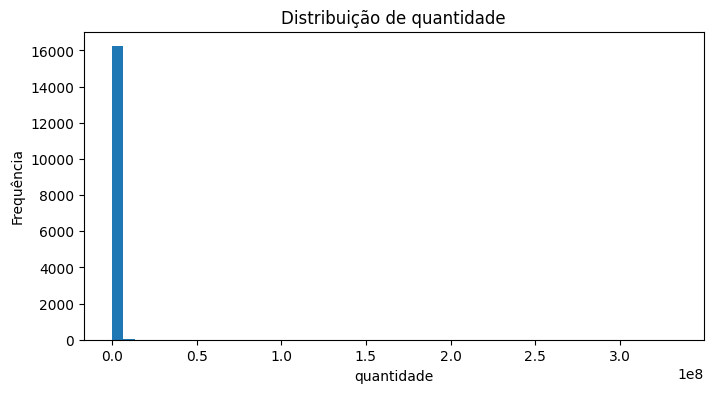

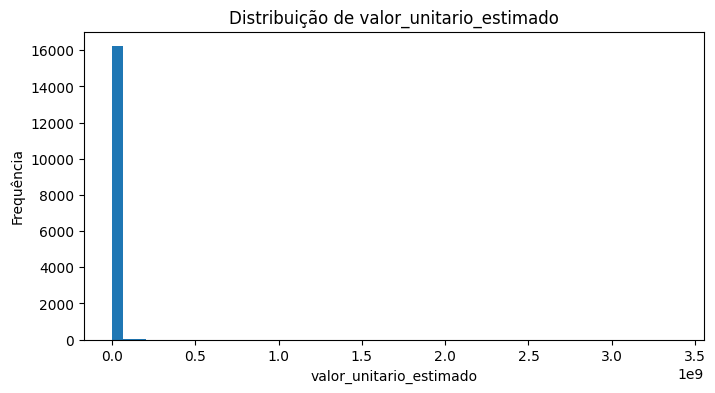

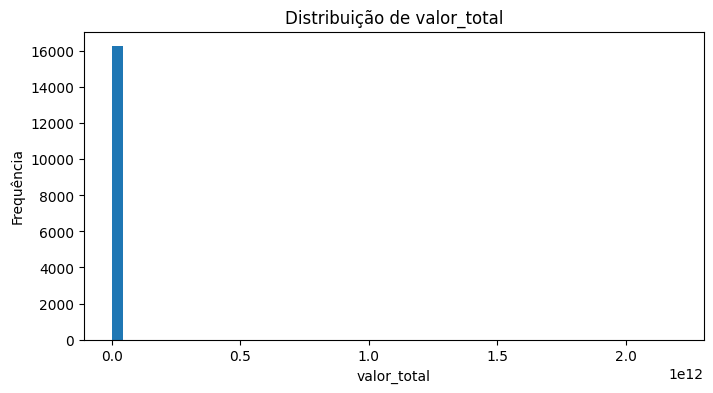

In [ ]:
for coluna in variaveis:
    plt.figure(figsize=(8, 4))

    plt.hist(
        dados[coluna].dropna(),
        bins=50
    )

    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")

    plt.show()

### 4.4.2 Boxplots das variáveis numéricas

Os boxplots são utilizados para visualizar a região central das
distribuições e a presença de valores distantes dos quartis.

Como as variáveis apresentam valores de magnitudes muito diferentes,
inicialmente são apresentados os boxplots na escala original.

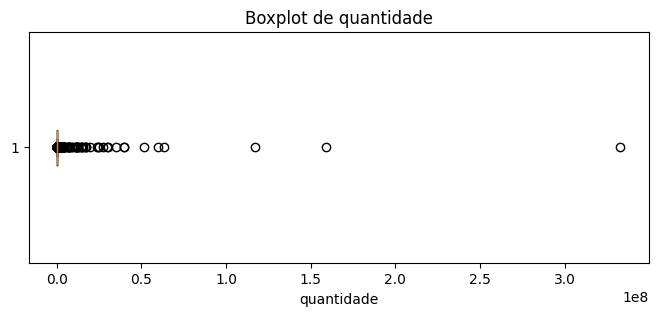

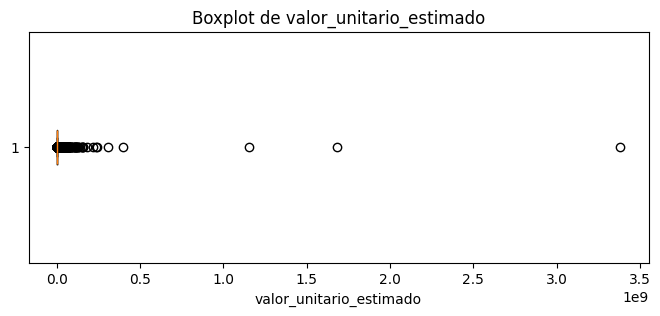

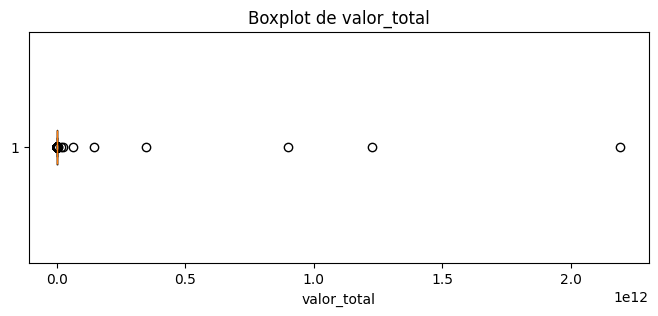

In [ ]:
for coluna in variaveis:
    plt.figure(figsize=(8, 3))

    plt.boxplot(
        dados[coluna].dropna(),
        vert=False
    )

    plt.title(f"Boxplot de {coluna}")
    plt.xlabel(coluna)

    plt.show()

### 4.4.3 Visualização após transformação logarítmica

Devido à forte assimetria observada na escala original, também foram
visualizadas as distribuições após a aplicação da transformação
`log1p`.

Essa transformação comprime valores muito elevados, permitindo observar
melhor a estrutura da distribuição sem excluir os registros extremos.

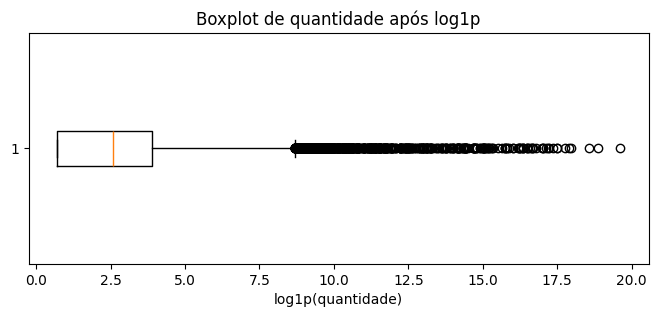

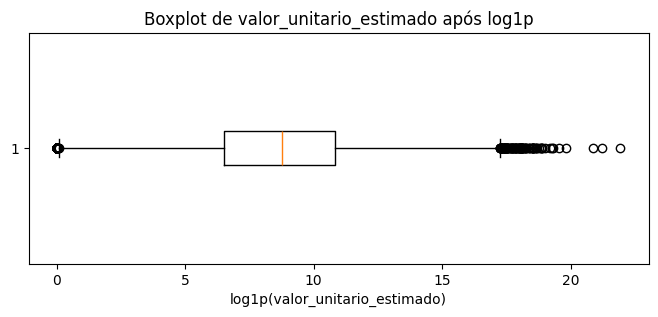

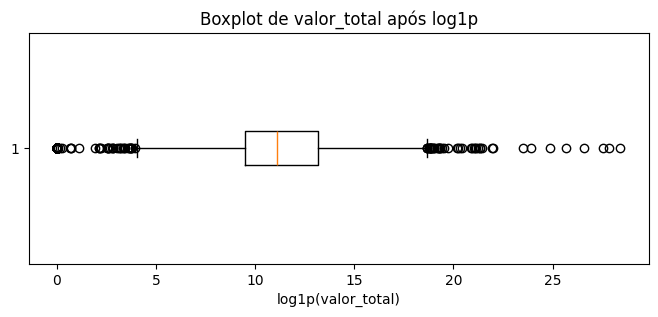

In [ ]:
for coluna in variaveis:
    serie_log = np.log1p(dados[coluna].dropna())

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        serie_log,
        vert=False
    )

    plt.title(f"Boxplot de {coluna} após log1p")
    plt.xlabel(f"log1p({coluna})")

    plt.show()

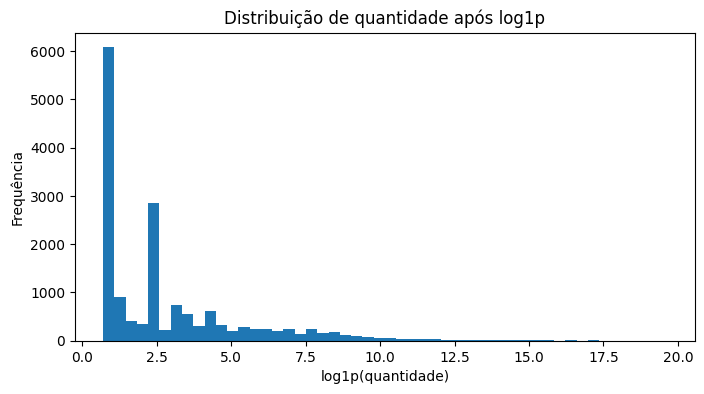

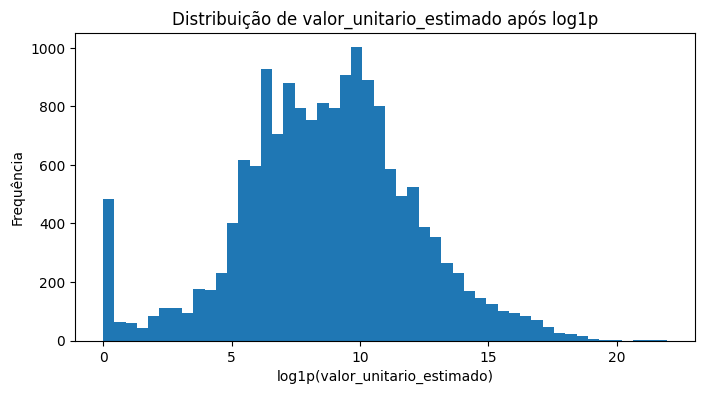

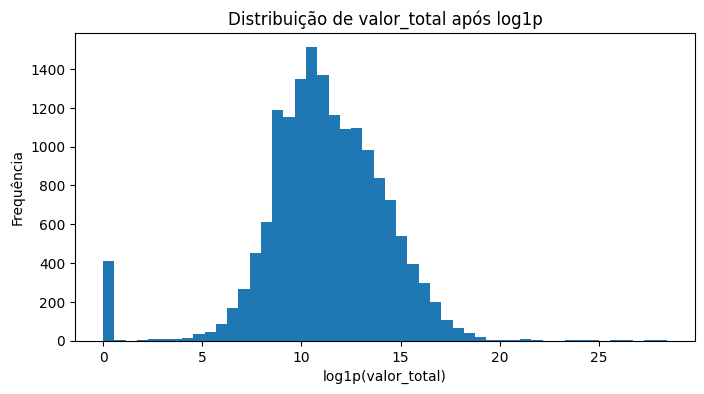

In [ ]:
for coluna in variaveis:
    serie_log = np.log1p(dados[coluna].dropna())

    plt.figure(figsize=(8, 4))

    plt.hist(
        serie_log,
        bins=50
    )

    plt.title(f"Distribuição de {coluna} após log1p")
    plt.xlabel(f"log1p({coluna})")
    plt.ylabel("Frequência")

    plt.show()

## 4.5 Identificação de possíveis outliers

Após analisar as distribuições das variáveis, será utilizado o método
do intervalo interquartil (IQR) para identificar observações
estatisticamente distantes da região central dos dados.

O IQR é calculado pela diferença entre o terceiro quartil (Q3) e o
primeiro quartil (Q1). Serão considerados possíveis outliers os valores
inferiores a Q1 - 1,5 × IQR ou superiores a Q3 + 1,5 × IQR.


In [ ]:
resultado_outliers = []

for coluna in variaveis:
    serie = dados[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = serie[
        (serie < limite_inferior) |
        (serie > limite_superior)
    ]

    resultado_outliers.append({
        "variavel": coluna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "quantidade_outliers": len(outliers),
        "percentual_outliers": (
            len(outliers) / len(serie) * 100
        )
    })

resumo_outliers = pd.DataFrame(resultado_outliers)

display(resumo_outliers)

,variavel,Q1,Q3,IQR,limite_inferior,limite_superior,quantidade_outliers,percentual_outliers
0,quantidade,1.000,48.0000,47.0000,-69.50000,1.185000e+02,2979,18.314275
1,valor_unitario_estimado,675.295,49599.6550,48924.3600,-72711.24500,1.229862e+05,2820,17.336776
2,valor_total,13186.140,517836.6375,504650.4975,-743789.60625,1.274812e+06,2641,16.236321


### Interpretação
O método do IQR identificou possíveis outliers nas três variáveis analisadas. Foram encontrados aproximadamente 18,31% de valores extremos em quantidade, 17,34% em valor_unitario_estimado e 16,24% em valor_total.
Como a proporção de registros sinalizados é relativamente alta, esses valores não devem ser removidos automaticamente.

## 4.6 Investigação dos maiores e menores valores

A identificação estatística de possíveis outliers não é suficiente para
classificar um registro como erro. Em contratações públicas, valores e
quantidades muito elevados podem representar situações legítimas.

Por esse motivo, serão inspecionados alguns dos maiores e menores valores
das variáveis analisadas, considerando também informações de contexto do
item, como ano, descrição, categoria e unidade de medida.

In [ ]:
colunas_contexto = [
    "ano_origem",
    "id_compra_item",
    "descricao_resumida",
    "nome_grupo_catser",
    "unidade_medida",
    "quantidade",
    "valor_unitario_estimado",
    "valor_total"
]

colunas_contexto = [
    coluna for coluna in colunas_contexto
    if coluna in df.columns
]

for coluna in variaveis:

    print(f"\n5 MAIORES VALORES DE {coluna}")

    maiores = (
        df[colunas_contexto]
        .sort_values(by=coluna, ascending=False)
        .head(5)
    )

    display(maiores)

    print(f"\n5 MENORES VALORES DE {coluna}")

    menores = (
        df[colunas_contexto]
        .sort_values(by=coluna, ascending=True)
        .head(5)
    )

    display(menores)



5 MAIORES VALORES DE quantidade


,ano_origem,id_compra_item,descricao_resumida,nome_grupo_catser,unidade_medida,quantidade,valor_unitario_estimado,valor_total
13494,2024,4430200690054202300001,Infraestrutura como servico - iaas Infraestrut...,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UND SERVIÇO EM NUVEM,332937580.0,5.6200000000,1871109199.6000
8183,2025,8060300590756202400001,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UN,159286385.0,0.2496000000,39757881.6900
8726,2025,0700070590052202400004,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,117290000.0,0.2600000000,30495400.0000
7686,2025,2000050590014202500001,Infraestrutura como servico - iaas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UND SERVIÇO EM NUVEM,63339105.0,1.0000000000,63339105.0000
7681,2025,2501100600381202500001,INFRAESTRUTURA COMO SERVICO - IAAS INFRAESTRUT...,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UND SERVIÇO EM NUVEM,59937876.0,1.7700000000,106090040.5200



5 MENORES VALORES DE quantidade


,ano_origem,id_compra_item,descricao_resumida,nome_grupo_catser,unidade_medida,quantidade,valor_unitario_estimado,valor_total
8132,2025,2400030700118202500001,Software como Servico - Saas Software como Ser...,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UND SERVIÇO TÉCNICO,1.0,210.6000000000,210.6000
12608,2024,9108470590080202400003,Outros Serviços para a Infraestrutura de Tecno...,SERVICOS PARA A INFRAESTRUTURA DE TECNOLOGIA...,UND SERVIÇO TÉCNICO,1.0,4107667.8800000000,4107667.8800
12611,2024,8060300590563202400001,Outros Serviços para a Infraestrutura de Tecno...,SERVICOS PARA A INFRAESTRUTURA DE TECNOLOGIA...,UND SERVIÇO TÉCNICO,1.0,4629939.3600000000,4629939.3600
12612,2024,9250670600067202400001,Outros Serviços para a Infraestrutura de Tecno...,SERVICOS PARA A INFRAESTRUTURA DE TECNOLOGIA...,UND SERVIÇO TÉCNICO,1.0,19875.0000000000,19875.0000
12613,2024,3930090690030202400001,Outros Serviços para a Infraestrutura de Tecno...,SERVICOS PARA A INFRAESTRUTURA DE TECNOLOGIA...,UST,1.0,31059.6700000000,31059.6700



5 MAIORES VALORES DE valor_unitario_estimado


...

,ano_origem,id_compra_item,descricao_resumida,nome_grupo_catser,unidade_medida,quantidade,valor_unitario_estimado,valor_total
16265,2024,9267540590004202400008,Outros Serviços para a Infraestrutura de Tecno...,SERVICOS PARA A INFRAESTRUTURA DE TECNOLOGIA...,UND SERVIÇO TÉCNICO,850.0,0E-10,0.0000
9290,2025,9267290590008202400001,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,1.0,0E-10,0.0000
9254,2025,9281380590001202500002,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,36.0,0E-10,0.0000
9198,2025,9276780690116202500002,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,20.0,0E-10,0.0000
13469,2024,1559040500137202300002,Infraestrutura como servico - iaas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UND SERVIÇO EM NUVEM,14000.0,0E-10,0.0000



5 MAIORES VALORES DE valor_total


,ano_origem,id_compra_item,descricao_resumida,nome_grupo_catser,unidade_medida,quantidade,valor_unitario_estimado,valor_total
13508,2024,3890540600017202400001,Infraestrutura como Servico - Iaas Infraestrut...,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,14811660.0,148116.6000000000,2193852719556.0000
12966,2024,7915000600026202400001,"Manutenção de Software (Corretiva, Preventiva,...",SERVIÇOS DE MANUTENÇÃO E SUSTENTAÇÃO DE SOFTWARE,UND SERVIÇO TÉCNICO,35000000.0,35000.0000000000,1225000000000.0000
8242,2025,3894210700011202600002,Software como Servico - Saas Software como Ser...,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UND SERVIÇO EM NUVEM,30000000.0,30000.0000000000,900000000000.0000
7729,2025,9860010600298202500001,Infraestrutura como servico - iaas Infraestrut...,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,576000.0,602496.0000000000,347037696000.0000
12652,2024,9274950700006202400001,"Serviços de Pesquisa, Análise e Desenvolviment...","SERVIÇOS DE PESQUISA,ANÁLISE E DESENVOLVIMENTO...",UNIDADE,11960000.0,11960.0000000000,143041600000.0000



5 MENORES VALORES DE valor_total


,ano_origem,id_compra_item,descricao_resumida,nome_grupo_catser,unidade_medida,quantidade,valor_unitario_estimado,valor_total
16265,2024,9267540590004202400008,Outros Serviços para a Infraestrutura de Tecno...,SERVICOS PARA A INFRAESTRUTURA DE TECNOLOGIA...,UND SERVIÇO TÉCNICO,850.0,0E-10,0.0000
8949,2025,9306750690002202400001,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,1.0,0E-10,0.0000
8967,2025,9271050590017202500001,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,1.0,0E-10,0.0000
8968,2025,9271050590009202500001,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,12.0,0E-10,0.0000
9019,2025,9308290590044202500001,Software como Servico - Saas,SERVIÇOS DE COMPUTAÇÃO EM NUVEM,UNIDADE,1.0,0E-10,0.0000


### Interpretação
A inspeção dos maiores e menores valores mostrou que os extremos possuem relação com o tipo de serviço e com a forma de contratação. As maiores quantidades aparecem principalmente em serviços de computação em nuvem, com valores unitários baixos, enquanto alguns dos maiores valores unitários estão associados a itens com quantidade igual a 1.    Texto colado


## 4.7 Comparação por arquivo de origem
A comparação agrupa os representantes selecionados por `ano_origem`, que identifica o arquivo de onde veio a observação mantida. Um item repetido entre arquivos entra apenas no ano de sua versão selecionada. Isso não representa automaticamente a evolução anual das contratações; para esse objetivo é necessário usar o ano da contratação e considerar a data de corte de 2026.

In [ ]:
resumo_anual = []

for ano, grupo in df.groupby("ano_origem"):
    for coluna in variaveis:
        serie = pd.to_numeric(grupo[coluna], errors="coerce").dropna()

        resumo_anual.append({
            "ano": ano,
            "variavel": coluna,
            "registros": len(serie),
            "media": serie.mean(),
            "mediana": serie.median(),
            "P95": serie.quantile(0.95),
            "P99": serie.quantile(0.99),
            "maximo": serie.max()
        })

resumo_anual = pd.DataFrame(resumo_anual)

display(resumo_anual)

,ano,variavel,registros,media,mediana,P95,P99,maximo
0,2021,quantidade,19,7.252632e+01,1.000,3.400000e+02,6.280000e+02,7.000000e+02
1,2021,valor_unitario_estimado,19,1.203696e+04,2685.000,4.008449e+04,4.789285e+04,4.984494e+04
2,2021,valor_total,19,2.164695e+04,21480.000,4.912679e+04,4.970131e+04,4.984494e+04
3,2022,quantidade,239,1.942678e+01,1.000,6.000000e+01,5.589600e+02,1.000000e+03
4,2022,valor_unitario_estimado,239,1.870991e+05,4445.000,5.213048e+04,2.921479e+05,4.019520e+07
5,2022,valor_total,239,1.950587e+05,10976.640,7.050000e+04,2.921479e+05,4.019520e+07
6,2023,quantidade,592,2.799642e+04,1.000,5.610000e+02,5.137776e+04,1.249920e+07
7,2023,valor_unitario_estimado,592,5.677541e+05,5550.000,1.124713e+06,1.920775e+07,4.807800e+07
8,2023,valor_total,592,8.524023e+05,17699.335,4.428793e+06,1.960263e+07,4.807800e+07
9,2024,quantidade,3807,1.358160e+05,12.000,3.235000e+03,1.208281e+05,3.329376e+08


### Interpretação
A comparação por ano mostra diferenças importantes nas distribuições. 2024 e 2025 concentram os maiores valores extremos, principalmente em quantidade e valor_total.
Em praticamente todos os anos, as médias são muito maiores que as medianas, indicando que poucos registros de valor muito elevado influenciam fortemente a média.
Também existe grande diferença na quantidade de registros entre os anos: por exemplo, há apenas 19 registros em 2021, enquanto 2025 possui 10.836.

## 4.8 Avaliação de transformações e escalonamento

As variáveis analisadas apresentaram forte assimetria positiva e
presença de valores extremos.
Serão comparadas a transformação logarítmica (`log1p`) e diferentes
formas de escalonamento, sem remover os valores extremos nesta etapa.

In [ ]:
dados_log = dados.copy()
assert not dados.lt(0).any().any(), "Revisar valores negativos antes de aplicar log1p."
for coluna in variaveis:
    dados_log[coluna] = np.log1p(dados[coluna])
display(pd.DataFrame({
    "Assimetria original": dados.skew(),
    "Assimetria após log1p": dados_log.skew(),
}))

,Assimetria original,Assimetria após log1p
quantidade,77.050170,1.748415
valor_unitario_estimado,84.950245,-0.153933
valor_total,85.700579,-0.824565


### Interpretação
A transformação log1p reduziu fortemente a assimetria das três variáveis. Em quantidade, a assimetria caiu de 77,05 para 1,75; em valor_unitario_estimado, de 84,95 para -0,15; e em valor_total, de 85,70 para -0,82.

### Comparação de técnicas de escalonamento

Além da transformação logarítmica, foram avaliadas três técnicas de
escalonamento: `StandardScaler`, `MinMaxScaler` e `RobustScaler`.

O objetivo é verificar alternativas para colocar as variáveis em escalas
comparáveis antes da clusterização, reduzindo o risco de uma variável
dominar o cálculo das distâncias apenas por possuir valores numericamente
maiores.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Para esta comparação, utilizamos apenas registros completos
# das três variáveis, sem alterar a base original.
dados_scaler = dados[variaveis].dropna().copy()

standard = StandardScaler()
minmax = MinMaxScaler()
robust = RobustScaler()

dados_standard = pd.DataFrame(
    standard.fit_transform(dados_scaler),
    columns=variaveis
)

dados_minmax = pd.DataFrame(
    minmax.fit_transform(dados_scaler),
    columns=variaveis
)

dados_robust = pd.DataFrame(
    robust.fit_transform(dados_scaler),
    columns=variaveis
)

print("StandardScaler")
display(dados_standard.describe())

print("MinMaxScaler")
display(dados_minmax.describe())

print("RobustScaler")
display(dados_robust.describe())

StandardScaler


,quantidade,valor_unitario_estimado,valor_total
count,1.626600e+04,1.626600e+04,1.626600e+04
mean,-1.310481e-18,-4.368270e-18,2.620962e-18
std,1.000031e+00,1.000031e+00,1.000031e+00
min,-2.921621e-02,-3.988448e-02,-1.444275e-02
25%,-2.921621e-02,-3.986335e-02,-1.444213e-02
50%,-2.921284e-02,-3.968072e-02,-1.443967e-02
75%,-2.920180e-02,-3.833286e-02,-1.441825e-02
max,1.020686e+02,1.057968e+02,1.037734e+02


MinMaxScaler


,quantidade,valor_unitario_estimado,valor_total
count,1.626600e+04,1.626600e+04,1.626600e+04
mean,2.861590e-04,3.768492e-04,1.391564e-04
std,9.794829e-03,9.448809e-03,9.635334e-03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.996005e-07,6.010495e-09
50%,3.303923e-08,1.925203e-06,2.962824e-08
75%,1.411676e-07,1.466043e-05,2.360398e-07
max,1.000000e+00,1.000000e+00,1.000000e+00


RobustScaler


,quantidade,valor_unitario_estimado,valor_total
count,1.626600e+04,1.626600e+04,1.626600e+04
mean,2.026853e+03,2.592686e+01,6.048220e+02
std,6.938440e+04,6.534070e+02,4.188741e+04
min,-2.340426e-01,-1.331322e-01,-1.288020e-01
25%,-2.340426e-01,-1.193294e-01,-1.026728e-01
50%,0.000000e+00,9.283481e-18,0.000000e+00
75%,7.659574e-01,8.806706e-01,8.973272e-01
max,7.083778e+06,6.915219e+04,4.347271e+06


### Escalonamento após transformação logarítmica

Como a transformação `log1p` reduziu substancialmente a assimetria das
variáveis, será avaliado o escalonamento dos dados após essa transformação.

Serão comparados `StandardScaler` e `RobustScaler`, com o objetivo de
verificar qual abordagem é mais adequada diante da presença de valores
extremos.


In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

dados_completos = dados[variaveis].dropna().copy()

# Primeiro aplica log1p
dados_log = np.log1p(dados_completos)

# Depois aplica os escalonadores
standard = StandardScaler()
robust = RobustScaler()

log_standard = pd.DataFrame(
    standard.fit_transform(dados_log),
    columns=variaveis
)

log_robust = pd.DataFrame(
    robust.fit_transform(dados_log),
    columns=variaveis
)

print("log1p + StandardScaler")
display(log_standard.describe())

print("log1p + RobustScaler")
display(log_robust.describe())

log1p + StandardScaler


,quantidade,valor_unitario_estimado,valor_total
count,1.626600e+04,1.626600e+04,1.626600e+04
mean,-1.223115e-16,3.844077e-17,-8.387078e-17
std,1.000031e+00,1.000031e+00,1.000031e+00
min,-7.992626e-01,-2.535088e+00,-3.589464e+00
25%,-7.992626e-01,-6.329055e-01,-5.385979e-01
50%,-1.087729e-01,2.828220e-02,-2.561984e-02
75%,3.806970e-01,6.208288e-01,6.417502e-01
max,6.183949e+00,3.869738e+00,5.548884e+00


log1p + RobustScaler


,quantidade,valor_unitario_estimado,valor_total
count,16266.000000,16266.000000,16266.000000
mean,0.092184,-0.022558,0.021705
std,0.847513,0.797642,0.847234
min,-0.585181,-2.044588,-3.019316
25%,-0.585181,-0.527375,-0.434599
50%,0.000000,0.000000,0.000000
75%,0.414819,0.472625,0.565401
max,5.332998,3.064011,4.722763


### Interpretação dos escalonamentos
Nos dados originais, o StandardScaler e o MinMaxScaler ainda sofrem bastante influência dos valores extremos. No MinMaxScaler, por exemplo, a maior parte dos dados ficou muito próxima de zero, enquanto poucos valores extremos chegaram a 1.
O RobustScaler foi menos sensível aos extremos por utilizar a mediana e o intervalo interquartil como referência, embora os valores muito altos continuem aparecendo.
Depois da aplicação do log1p, tanto o StandardScaler quanto o RobustScaler apresentaram distribuições bem mais equilibradas. Para a preparação dos dados antes da clusterização, log1p + RobustScaler é uma boa alternativa, pois combina a redução da assimetria com um escalonamento menos sensível aos valores extremos.

## 4.9 Conclusão
A análise mostrou que quantidade, valor_unitario_estimado e valor_total possuem forte assimetria e muitos valores extremos. Como esses valores podem representar características reais das contratações, eles não devem ser removidos ou limitados automaticamente.
A transformação log1p reduziu bastante a assimetria das três variáveis. Para a etapa de clusterização, a combinação log1p + RobustScaler foi considerada uma alternativa adequada, pois reduz o impacto dos valores muito elevados e deixa as variáveis em escalas mais comparáveis.
Assim, é valido manter os registros válidos, aplicar transformação e escalonamento antes da clusterização e remover dados apenas quando houver evidência de erro ou inconsistência.